# Decision Trees and the CART Algorithm

A **decision tree** is a supervised learning algorithm used for both classification and regression tasks. It works by recursively splitting the data based on feature values, creating a tree-like structure of decisions.

### Key Concepts
- **Root node**: The topmost decision node, representing the best overall split
- **Internal nodes**: Decision points that test a feature condition
- **Leaf nodes (terminal nodes)**: Final predictions — the class label (classification) or value (regression)
- **Branches**: Connections between nodes representing the outcome of a test

### The CART Algorithm
**CART** (Classification and Regression Trees) is the most widely used decision tree algorithm. It:
1. Uses **binary splits** — each node splits into exactly two branches
2. Uses **Gini impurity** (classification) or **variance reduction** (regression) to evaluate splits
3. Greedily selects the split that minimizes impurity at each step

---

## 1. Motivating Example: Heart Disease Prediction

Consider a dataset where we want to predict whether a patient has heart disease based on three features:

| # | Chest Pain | Good Blood Circulation | Blocked Arteries | Heart Disease |
|---|------------|----------------------|------------------|---------------|
| 1 | No         | No                   | No               | No            |
| 2 | Yes        | Yes                  | Yes              | Yes           |
| 3 | Yes        | Yes                  | No               | No            |
| ... | ...      | ...                  | ...              | ...           |

We select **one feature at a time** and build a single-condition decision tree for each. The goal is to find which feature produces the **purest** (most homogeneous) splits.

### Visual: A Simple Decision Tree

Below we visualize what a simple decision tree looks like:

In [ ]:
from IPython.display import Image
Image(filename='1.1.Simple_Decision_Tree.png')

### Decision Tree with Sample Counts

In [ ]:
from IPython.display import Image
Image(filename='1.2.Simple_Decision_Tree_with_Number.png')

In [ ]:
from IPython.display import Image
Image(filename='1.3.Decision_Tree_with_number.png')

In [ ]:
from IPython.display import Image
Image(filename='1.3.nodes.png')

In [ ]:
from IPython.display import Image
Image(filename='1.4.nodes_example.png')

## 2. Building Single-Feature Trees

For each candidate feature, we build a one-level tree and count the outcomes:

**1. Chest Pain:**
```
       Chest Pain
       /        \
     Yes         No
    /   \      /   \
  HD:105 No:39  HD:34 No:125
```

**2. Good Blood Circulation:**
```
   Good Blood Circulation
       /            \
     Yes             No
    /   \          /   \
  HD:37 No:127  HD:100 No:33
```

**3. Blocked Arteries:**
```
     Blocked Arteries
       /          \
     Yes           No
    /   \        /   \
  HD:92 No:31  HD:45 No:129
```

We call any leaf that does **not** classify 100% correctly an **impure** leaf node. The question is: which feature gives us the **least** impurity?

## 3. Gini Impurity

**Gini impurity** measures how often a randomly chosen element would be misclassified if it were randomly labeled according to the distribution of labels in the node.

$$ \text{Gini Impurity} = 1 - P(\text{Yes})^2 - P(\text{No})^2 $$

- A Gini of **0** means the node is perfectly pure (all samples belong to one class)
- A Gini of **0.5** means maximum impurity (50/50 split for binary classification)

### Gini vs. Entropy

An alternative to Gini impurity is **information entropy**:

$$ \text{Entropy} = -\sum_{i} P_i \log_2(P_i) $$

Both metrics measure impurity, but Gini is computationally simpler and is the default in CART. In practice, they usually produce similar trees.

---

### Calculating Gini for "Good Blood Circulation"

**Left branch** (Good Blood Circulation = Yes): HD:37, No:127

In [ ]:
# Left branch: Gini impurity
1 - (105 / (105 + 39))**2 - (39 / (105 + 39))**2

**Left branch Gini:** 0.395

In [ ]:
# Right branch: Gini impurity
1 - (34 / (34 + 125))**2 - (125 / (34 + 125))**2

**Right branch Gini:** 0.336

### Weighted Gini Impurity

To get the overall Gini for a split, we compute the **weighted average** of the child node Gini values, weighted by the number of samples in each branch:

$$ \text{Weighted Gini} = \frac{n_{\text{left}}}{n_{\text{total}}} \cdot G_{\text{left}} + \frac{n_{\text{right}}}{n_{\text{total}}} \cdot G_{\text{right}} $$

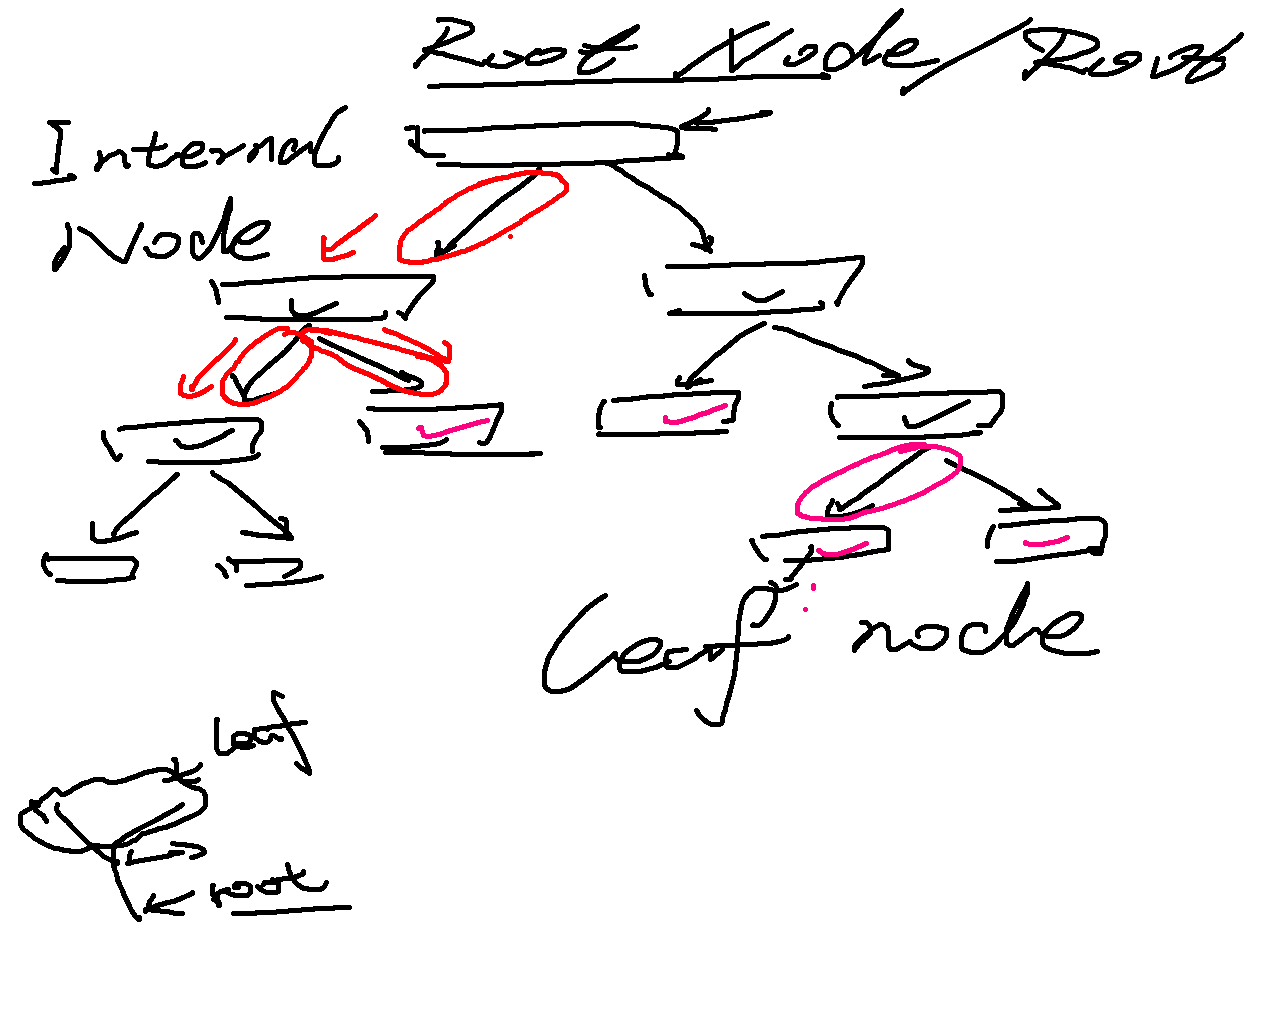

In [ ]:
# Weighted Gini impurity for this feature
(144 / (144 + 159)) * 0.395 + (159 / (144 + 159)) * 0.336

## 4. Comparing All Features

By the same calculation for each feature:

| Feature                | Weighted Gini |
|------------------------|---------------|
| Chest Pain             | 0.364         |
| Good Blood Circulation | **0.360**     |
| Blocked Arteries       | 0.381         |

**Good Blood Circulation** has the lowest Gini (most pure splits), so it becomes the **root node**.

---

## 5. Building the Full Tree

After selecting the root node, we repeat the process recursively for each child node:

```
          Good Blood Circulation
           /                  \
    Blocked Arteries      Chest Pain
       /      \            /       \
     CP     13/102      92/3       BA
    / \                           /  \
 17/3  7/22                    8/0  0/30
```

At each step, we choose the feature that produces the lowest weighted Gini impurity for that subset of data.

After selecting the root (Good Blood Circulation):
- In the left branch: **Blocked Arteries** has a Gini of 0.290 (lower than Chest Pain at 0.3)
- So Blocked Arteries is chosen as the next split on the left side

---

## 6. Pruning

Decision trees tend to **overfit** — they memorize training data noise. **Pruning** addresses this:

### Pre-pruning (Early Stopping)
- Set a **maximum tree depth**
- Require a **minimum number of samples** to split a node
- Require a **minimum impurity decrease** for a split

### Post-pruning
- Grow the full tree, then remove branches that provide little predictive power
- **Cost-complexity pruning** balances tree complexity vs. accuracy using a parameter \(\alpha\)

---

## 7. Thought Questions

1. **Numerical features**: How do you compute Gini for continuous numerical data?  
   *Answer: Sort the values, compute the average between consecutive pairs, and test each midpoint as a threshold (split into ≤ threshold vs > threshold). There is no need to include the maximum value as a threshold since it cannot split the data.*

2. **Ordinal features**: How do you compute Gini for ordinal data (e.g., preference ratings 1, 2, 3, 4)?  
   *Answer: Sort by the ordinal values, then use a ≤ threshold approach similar to numerical features.*

3. **Categorical (survey) features**: How do you compute Gini for unordered categorical data?  
   *Answer: Consider all possible subsets (combinations) of categories for the split. There is no need to include the combination of all categories, since it cannot produce a split.*